In [1]:
import mpemba

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

In [2]:
analytic = mpemba.special_potentials.AnalyticAsymmetricDoubleWellPotential(E_tilt=0.4, force_asymmetry=0.5, n=2, n2=5, x_min=-5, x_max=5)
x = np.linspace(-5, 5, 500)
analytic.comparisonPotential.plot_force(plot_range=x, color='y')
analytic.plot_force(plot_range=x)

[ 0.79467391 -0.07625104 -0.70549189  0.64237921]
[[ 4.97641137e-07  3.68772966e-07 -1.24437139e-08  1.60628322e-08]
 [ 3.68772966e-07  5.10571900e-07 -1.43265773e-09  1.53491609e-08]
 [-1.24437139e-08 -1.43265773e-09  1.19782502e-08 -2.88553222e-10]
 [ 1.60628322e-08  1.53491609e-08 -2.88553222e-10  3.42402178e-08]]


In [24]:
analytic.comparisonPotential.plot_a_2s(k_BT_max=1000)

<lambdifygenerated-26>:2: RuntimeWarning: overflow encountered in exp
  return -(1 - exp(-9.95658563829706*(x + 0.0762510434570258)**10))*(2.81094718425428e-13*exp(50.0*x)/(1.12437887370171e-14*exp(50.0*x) + 1) - 1.14774766056792e-29*exp(-100*x)/(1 + 2.29549532113584e-31*exp(-100*x))) + 99.5658563829706*(-0.4*x + 32.0*(0.25 - x**2)**2)*(x + 0.0762510434570258)**9*exp(-9.95658563829706*(x + 0.0762510434570258)**10) - 99.5658563829706*(x + 0.0762510434570258)**9*((1/2)*log(1 + 2.29549532113584e-31*exp(-100*x)) + (1/2)*log(1.12437887370171e-14*exp(50.0*x) + 1))*exp(-9.95658563829706*(x + 0.0762510434570258)**10) - (-128.0*x*(0.25 - x**2) - 0.4)*exp(-9.95658563829706*(x + 0.0762510434570258)**10)
<lambdifygenerated-26>:2: RuntimeWarning: invalid value encountered in divide
  return -(1 - exp(-9.95658563829706*(x + 0.0762510434570258)**10))*(2.81094718425428e-13*exp(50.0*x)/(1.12437887370171e-14*exp(50.0*x) + 1) - 1.14774766056792e-29*exp(-100*x)/(1 + 2.29549532113584e-31*exp(-100*x))) + 99

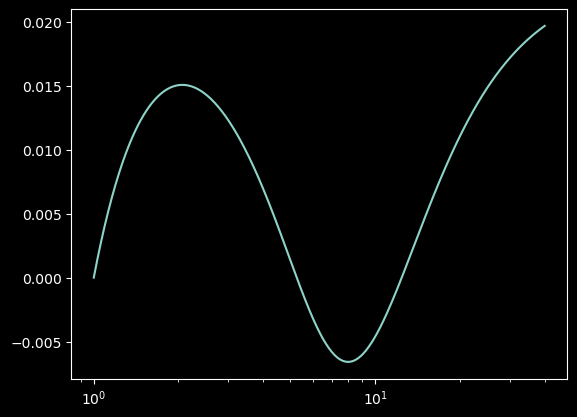

In [ ]:
U = analytic.comparisonPotential.U(x)
U_approx = analytic.U(x)
F = analytic.comparisonPotential.F(x)
F_approx = analytic.F(x)

Ts = np.logspace(0, np.log10(1000), len(x))
analytic.comparisonPotential.x_max=100
analytic.comparisonPotential.x_min=-100

analytic.x_max=100
analytic.x_min=-100
analytic.comparisonPotential.x_max=100
analytic.comparisonPotential.x_min=-100

a_2s = analytic.comparisonPotential.a_k_boltzmannIC(x=x, k_BT=Ts)
a_2s_approx = analytic.a_k_boltzmannIC(x=x, k_BT=Ts)
plt.close()
plt.semilogx(np.logspace(np.log10(1), np.log10(40), 500), a_2s_approx)
# analytic.comparisonPotential.plot_a_2s(k_BT_max=40, n_x=2000)
plt.show()
df = pd.DataFrame(np.array([U, U_approx, F, F_approx, Ts, a_2s, a_2s_approx]).T, columns = ['U', 'Ua', 'F', 'Fa', 'T', 'a2', 'a2a'], index=x)
df.index.name='x'
df.to_csv("analytic_params.csv")

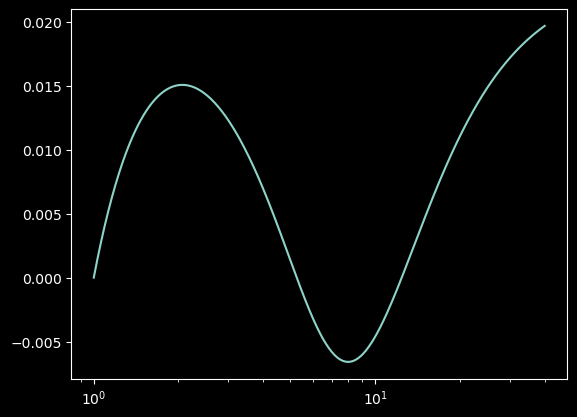

100

In [16]:
plt.close()
plt.semilogx(np.logspace(np.log10(1), np.log10(40), 500), a_2s_approx)
plt.show()
analytic.comparisonPotential.x_max

In [4]:
ensemble = mpemba.construct_simulated_ensemble(analytic, k_BTs=[22,4,1], num_particles=10_000)

100%|██████████| 9999/9999 [00:29<00:00, 340.11it/s]


In [6]:
ensemble.export_distances("analytic_distances.csv")